# Used Car Price Prediction — Full Data Analysis & Model Comparison

**Dataset:** `Used_Car_Prices.csv` — 8,128 used car listings with 4 features (`brand`, `km_driven`, `fuel`, `owner`) and target `selling_price` (₹).

**Goal:** Explore the data, clean and engineer features, train and compare multiple regression models, and pick the best-performing one for predicting used car selling price.

**Contents**
1. Initial Data Inspection
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
5. Train/Test Split & Scaling
6. Model Training & Comparison
7. Best Model — Feature Importance & Fit Quality
8. Save the Best Model
9. Conclusions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 120)


In [2]:
df = pd.read_csv('Used_Car_Prices.csv')
df.head(8)

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000
5,Hyundai,45000,Petrol,First Owner,440000
6,Maruti,175000,LPG,First Owner,96000
7,Maruti,5000,Petrol,Second Owner,45000


## 1. Initial Data Inspection

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (8128, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   brand          8128 non-null   object
 1   km_driven      8128 non-null   int64 
 2   fuel           8128 non-null   object
 3   owner          8128 non-null   object
 4   selling_price  8128 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 317.6+ KB


In [4]:
df.isnull().sum()

brand            0
km_driven        0
fuel             0
owner            0
selling_price    0
dtype: int64

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1678


In [6]:
df.describe()

,km_driven,selling_price
count,8.128000e+03,8.128000e+03
mean,6.981951e+04,6.382718e+05
std,5.655055e+04,8.062534e+05
min,1.000000e+00,2.999900e+04
25%,3.500000e+04,2.549990e+05
50%,6.000000e+04,4.500000e+05
75%,9.800000e+04,6.750000e+05
max,2.360457e+06,1.000000e+07


**Observations so far:**
- No missing values in any column — nice and clean on that front.
- **1,678 exact duplicate rows** (≈20.6% of the data) — these need to be dropped, otherwise the same record can leak into both train and test splits and inflate our accuracy estimates.
- `km_driven` max is **2,360,457 km**, which is not physically realistic for a passenger vehicle — this is almost certainly a data entry error and needs to be handled.
- `selling_price` ranges from ₹30,000 to ₹1,00,00,000 (1 crore) — a very wide range, spanning budget hatchbacks to luxury cars (BMW, Mercedes, Volvo).

## 2. Exploratory Data Analysis (EDA)

### 2.1 Target variable distribution

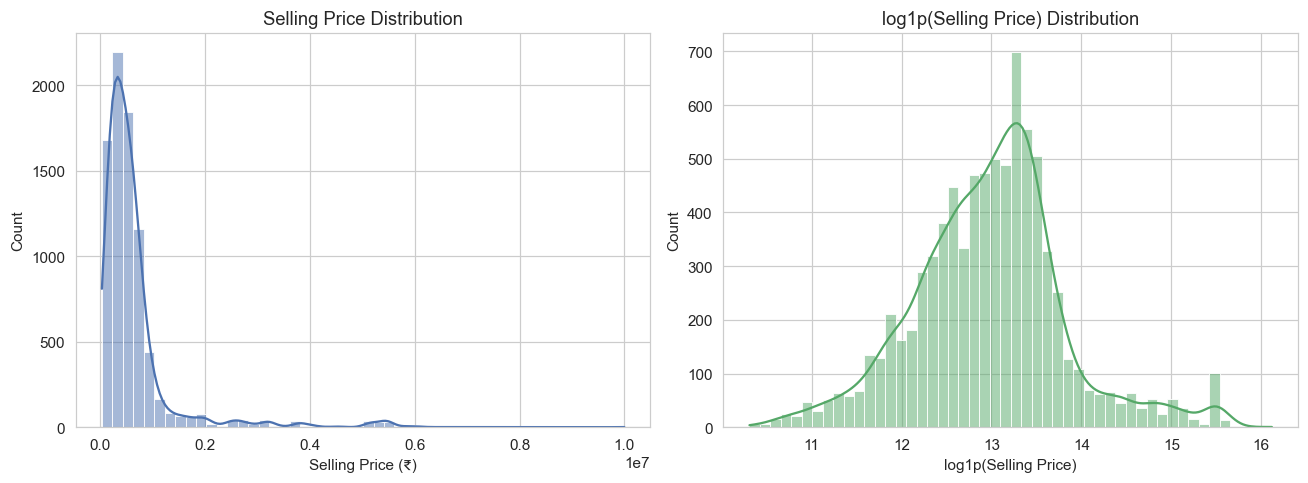

Selling price skewness: 4.193533440675855
Log selling price skewness: 0.22327004522860716


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['selling_price'], bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Selling Price Distribution')
axes[0].set_xlabel('Selling Price (₹)')
sns.histplot(np.log1p(df['selling_price']), bins=50, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('log1p(Selling Price) Distribution')
axes[1].set_xlabel('log1p(Selling Price)')
plt.tight_layout()
plt.show()

print("Selling price skewness:", df['selling_price'].skew())
print("Log selling price skewness:", np.log1p(df['selling_price']).skew())

`selling_price` is heavily right-skewed (skew ≈ 4.19) — a small number of very expensive cars stretch the distribution. A `log1p` transform brings skew down to ≈ 0.22, close to symmetric. **We'll model `log1p(selling_price)` as the target** and convert predictions back with `expm1` for evaluation on the real ₹ scale.

### 2.2 `km_driven` distribution

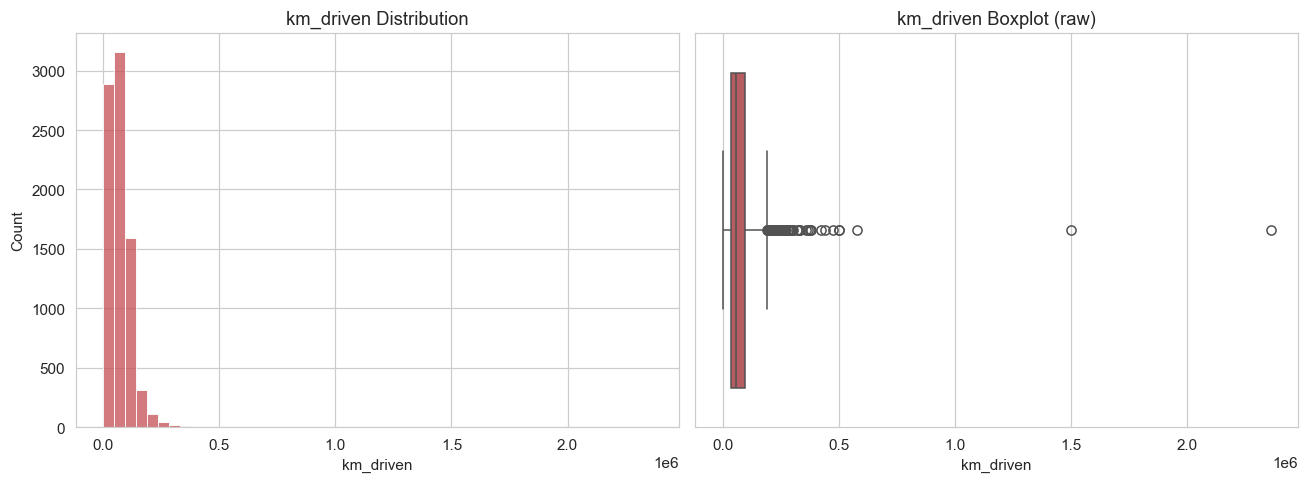

km_driven skewness: 11.170909783549087


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['km_driven'], bins=50, ax=axes[0], color='#C44E52')
axes[0].set_title('km_driven Distribution')
sns.boxplot(x=df['km_driven'], ax=axes[1], color='#C44E52')
axes[1].set_title('km_driven Boxplot (raw)')
plt.tight_layout()
plt.show()

print("km_driven skewness:", df['km_driven'].skew())

Extremely right-skewed (skew ≈ 11.2), and the boxplot makes the two extreme outliers near 1.5M and 2.36M km obvious — these dominate the whole chart and visually flatten everything else. We'll cap these in the cleaning step and apply `log1p` as well.

### 2.3 Categorical feature counts

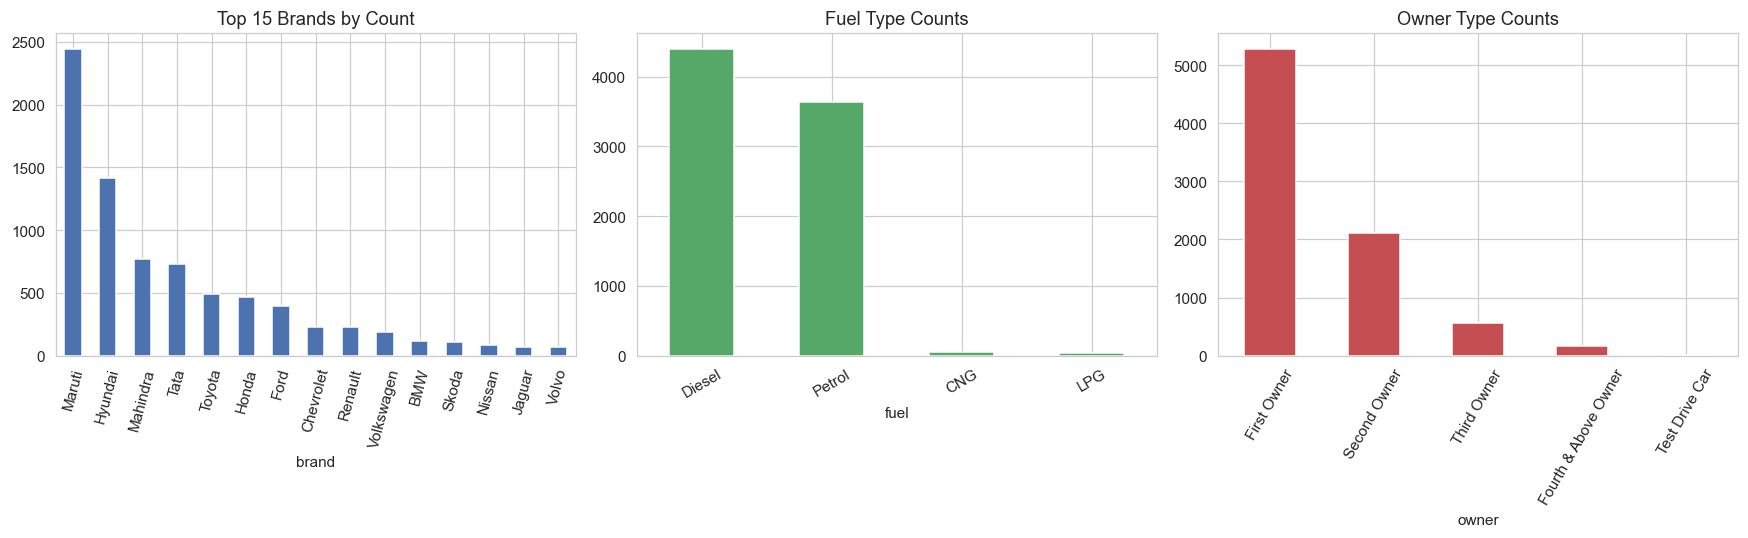

Brands: 32  | Fuels: 4  | Owner types: 5


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df['brand'].value_counts().head(15).plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 15 Brands by Count')
axes[0].tick_params(axis='x', rotation=75)
df['fuel'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Fuel Type Counts')
axes[1].tick_params(axis='x', rotation=30)
df['owner'].value_counts().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Owner Type Counts')
axes[2].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

print("Brands:", df['brand'].nunique(), " | Fuels:", df['fuel'].nunique(), " | Owner types:", df['owner'].nunique())

- **32 brands**, heavily dominated by Maruti (2,448) and Hyundai (1,415) — a long tail of rare brands (Kia, MG, Daewoo, Ashok, Opel, Peugeot each with ≤4 listings).
- **Fuel**: Diesel and Petrol dominate (4,402 / 3,631); CNG and LPG are rare (57 / 38).
- **Owner**: mostly First Owner (5,289) and Second Owner (2,105); Test Drive Car is a tiny but distinct category (5 rows, effectively brand-new cars) — this has a natural order, so it's a good candidate for ordinal encoding rather than one-hot.

### 2.4 Selling price vs. categorical features

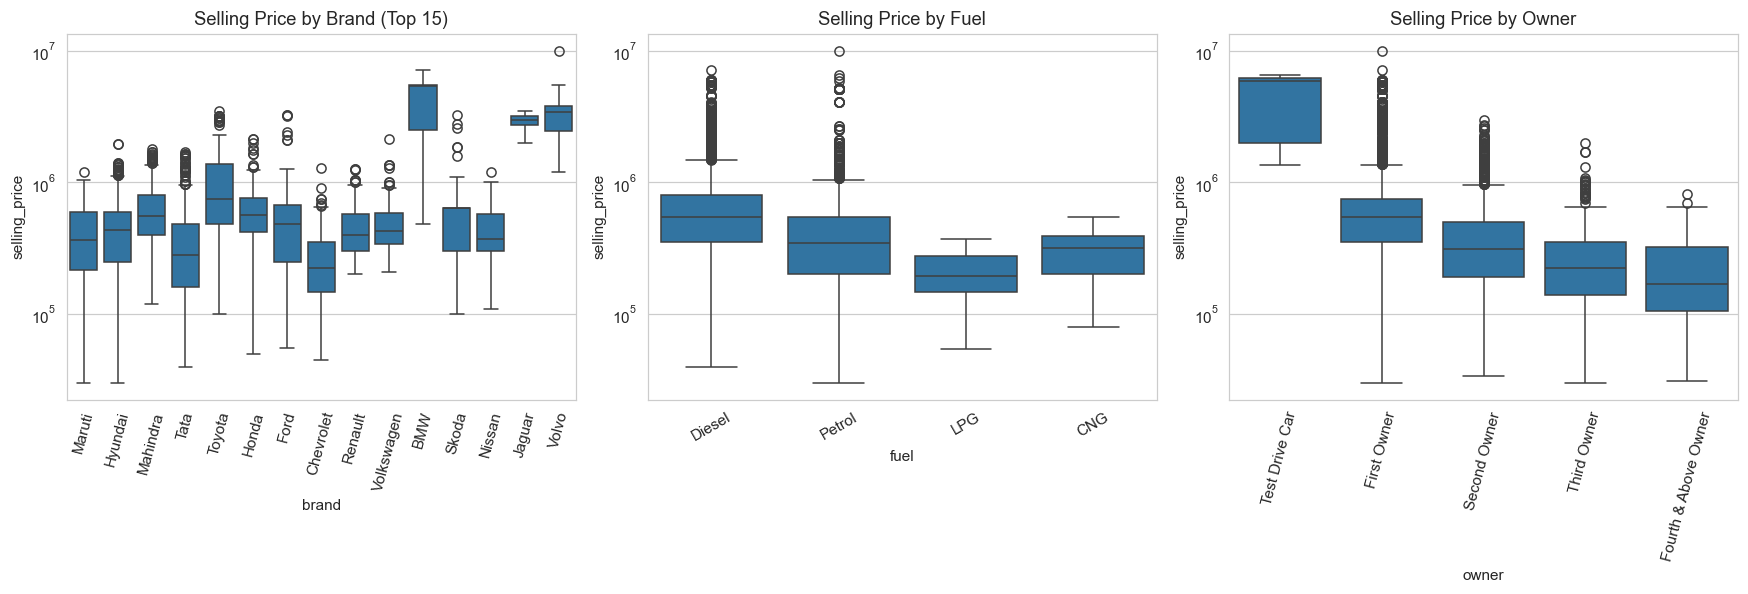

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
top_brands = df['brand'].value_counts().head(15).index
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='selling_price', ax=axes[0], order=top_brands)
axes[0].set_title('Selling Price by Brand (Top 15)')
axes[0].tick_params(axis='x', rotation=75)
axes[0].set_yscale('log')
sns.boxplot(data=df, x='fuel', y='selling_price', ax=axes[1])
axes[1].set_title('Selling Price by Fuel')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_yscale('log')
owner_order = ['Test Drive Car','First Owner','Second Owner','Third Owner','Fourth & Above Owner']
sns.boxplot(data=df, x='owner', y='selling_price', ax=axes[2], order=owner_order)
axes[2].set_title('Selling Price by Owner')
axes[2].tick_params(axis='x', rotation=75)
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

In [11]:
print("Mean selling_price by fuel:")
print(df.groupby('fuel')['selling_price'].mean().sort_values(ascending=False))
print()
print("Mean selling_price by owner:")
print(df.groupby('owner')['selling_price'].mean().reindex(owner_order))

Mean selling_price by fuel:
fuel
Diesel    791452.921627
Petrol    462441.061691
CNG       301017.491228
LPG       200421.052632
Name: selling_price, dtype: float64

Mean selling_price by owner:
owner
Test Drive Car          4.403800e+06
First Owner             7.830864e+05
Second Owner            3.929645e+05
Third Owner             2.840153e+05
Fourth & Above Owner    2.258132e+05
Name: selling_price, dtype: float64


Clear, intuitive signal in every categorical feature:
- **Brand** matters a lot — BMW, Volvo, Jaguar sit far above mass-market brands like Maruti and Chevrolet (log scale in the plot).
- **Diesel cars sell for ~71% more on average than Petrol**, and far more than CNG/LPG — diesel is associated with larger/higher-end vehicles in this market.
- **Owner count is strongly (and monotonically) associated with price** — First Owner cars are worth almost 3x Second Owner, and price keeps falling with more owners. Test Drive Car is the outlier — these are effectively brand-new demo vehicles, which explains the very high average.

### 2.5 `km_driven` vs. `selling_price`

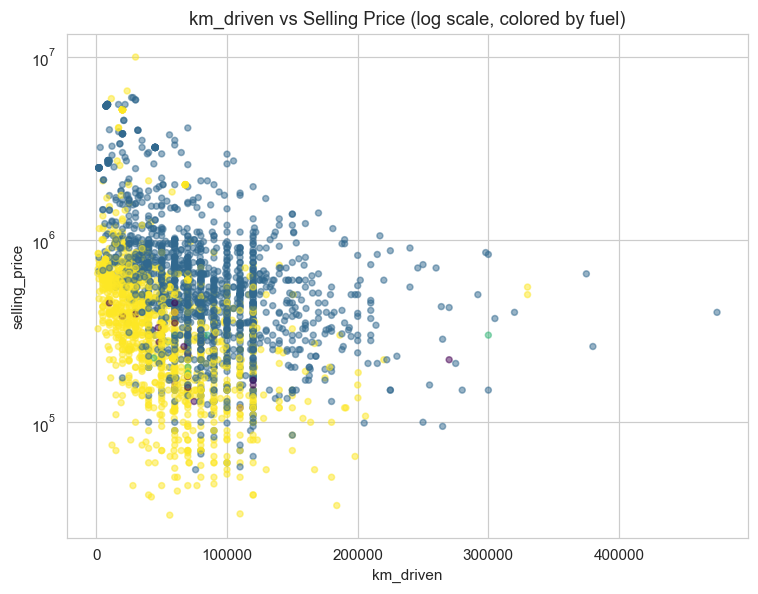

Correlation km_driven vs selling_price (Pearson): -0.22553375557218944
Correlation log_km vs log_price (Pearson): -0.3687574339147206


In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sample = df.sample(min(3000, len(df)), random_state=42)
ax.scatter(sample['km_driven'], sample['selling_price'], c=sample['fuel'].astype('category').cat.codes,
           alpha=0.5, cmap='viridis', s=15)
ax.set_xlabel('km_driven')
ax.set_ylabel('selling_price')
ax.set_yscale('log')
ax.set_title('km_driven vs Selling Price (log scale, colored by fuel)')
plt.tight_layout()
plt.show()

print("Correlation km_driven vs selling_price (Pearson):", df['km_driven'].corr(df['selling_price']))
print("Correlation log_km vs log_price (Pearson):", np.log1p(df['km_driven']).corr(np.log1p(df['selling_price'])))

Negative correlation as expected (more mileage → lower price), and it's notably stronger once both variables are log-transformed (-0.37 vs -0.23) — another point in favor of the log transform.

## 3. Data Cleaning

Based on the EDA above, two cleaning steps are needed before modeling:
1. **Drop exact duplicate rows** — with only 4 raw features, duplicate rows are almost certainly repeated records rather than coincidental matches, and leaving them in risks the *same* record appearing in both the train and test split (data leakage → falsely inflated accuracy).
2. **Remove unrealistic `km_driven` values** — values above 500,000 km are treated as data-entry errors and dropped.

Note: unlike `km_driven`, the high **`selling_price`** values are *not* removed — they correspond to genuine luxury brands (BMW, Audi, Mercedes-Benz, Volvo, Jaguar) and represent a real market segment the model should learn to predict, not an error.

In [13]:
before = df.shape[0]
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - df_clean.shape[0]} duplicate rows -> {df_clean.shape[0]} rows remain")

before = df_clean.shape[0]
df_clean = df_clean[df_clean['km_driven'] <= 500_000].reset_index(drop=True)
print(f"Dropped {before - df_clean.shape[0]} rows with unrealistic km_driven (>500,000) -> {df_clean.shape[0]} rows remain")

print()
print("Final cleaned shape:", df_clean.shape)
df_clean.describe()

Dropped 1678 duplicate rows -> 6450 rows remain
Dropped 3 rows with unrealistic km_driven (>500,000) -> 6447 rows remain

Final cleaned shape: (6447, 5)


,km_driven,selling_price
count,6447.000000,6.447000e+03
mean,73815.302001,5.242807e+05
std,48909.902418,5.342349e+05
min,1.000000,2.999900e+04
25%,39000.000000,2.500000e+05
50%,70000.000000,4.099990e+05
75%,100000.000000,6.415000e+05
max,500000.000000,1.000000e+07


## 4. Feature Engineering

- `log_km_driven` = `log1p(km_driven)` — reduce skew.
- `owner_ordinal` — owner has a natural order (more owners = older/more used), so it's encoded 0–4 rather than one-hot: `Test Drive Car=0, First=1, Second=2, Third=3, Fourth & Above=4`.
- `fuel` — one-hot encoded (4 columns, no natural order).
- `brand` — one-hot encoded (32 columns, no natural order).
- Target: `log1p(selling_price)`, inverted with `expm1` for evaluation on the real price scale.

In [14]:
owner_map = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4
}
brands = sorted(df_clean['brand'].unique().tolist())
fuels = sorted(df_clean['fuel'].unique().tolist())

X = pd.DataFrame(index=df_clean.index)
X['log_km_driven'] = np.log1p(df_clean['km_driven'])
X['owner_ordinal'] = df_clean['owner'].map(owner_map)
for f in fuels:
    X[f'fuel_{f}'] = (df_clean['fuel'] == f).astype(int)
for b in brands:
    X[f'brand_{b}'] = (df_clean['brand'] == b).astype(int)

y_log = np.log1p(df_clean['selling_price'])

print("Feature matrix shape:", X.shape)
print("Number of brands one-hot encoded:", len(brands))
print("Number of fuel types one-hot encoded:", len(fuels))

Feature matrix shape: (6447, 38)
Number of brands one-hot encoded: 32
Number of fuel types one-hot encoded: 4


## 5. Train/Test Split & Scaling

80/20 split. The `StandardScaler` is **fit on the training set only** and then applied to both — fitting it on the full dataset before splitting would leak test-set statistics (mean/std) into training, which would make the reported metrics optimistic and not trustworthy.

In [15]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_s = scaler.transform(X_test)         # transform test with train's stats

y_test_raw = np.expm1(y_test_log)

Train shape: (5157, 38)  Test shape: (1290, 38)


## 6. Model Training & Comparison

Nine regression models are trained on the identical scaled feature matrix and compared on the **held-out test set**, with predictions converted back from log-price to ₹ before scoring. 5-fold cross-validation (on the training set) is also reported to check that results are stable and not a lucky split.

Metrics:
- **R²** — variance explained (price scale)
- **RMSE** — root mean squared error (₹)
- **MAE** — mean absolute error (₹)
- **MAPE** — mean absolute percentage error (%)

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.001, random_state=42, max_iter=20000),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=7),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', C=10, epsilon=0.05),
    'XGBoost': XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, random_state=42, n_jobs=-1),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_s, y_train_log)
    pred_log = model.predict(X_test_s)
    pred_raw = np.clip(np.expm1(pred_log), 0, None)

    r2 = r2_score(y_test_raw, pred_raw)
    rmse = np.sqrt(mean_squared_error(y_test_raw, pred_raw))
    mae = mean_absolute_error(y_test_raw, pred_raw)
    mape = mean_absolute_percentage_error(y_test_raw, pred_raw) * 100
    cv_scores = cross_val_score(model, X_train_s, y_train_log, cv=5, scoring='r2', n_jobs=-1)

    results.append({'Model': name, 'R2 (price)': r2, 'RMSE (₹)': rmse, 'MAE (₹)': mae,
                     'MAPE (%)': mape, 'CV R2 mean': cv_scores.mean(), 'CV R2 std': cv_scores.std()})
    fitted_models[name] = model
    print(f"{name:20s} R2={r2:.4f}  RMSE={rmse:,.0f}  MAE={mae:,.0f}  MAPE={mape:.2f}%  CV R2={cv_scores.mean():.4f}+/-{cv_scores.std():.4f}")


Linear Regression    R2=0.5536  RMSE=318,257  MAE=178,713  MAPE=45.21%  CV R2=0.5491+/-0.0290
Ridge                R2=0.5536  RMSE=318,241  MAE=178,706  MAPE=45.21%  CV R2=0.5491+/-0.0290
Lasso                R2=0.5539  RMSE=318,143  MAE=178,647  MAPE=45.19%  CV R2=0.5494+/-0.0289
KNN Regressor        R2=0.5600  RMSE=315,957  MAE=176,781  MAPE=45.08%  CV R2=0.5292+/-0.0343
Decision Tree        R2=0.4612  RMSE=349,647  MAE=192,594  MAPE=47.34%  CV R2=0.4563+/-0.0357
Random Forest        R2=0.5240  RMSE=328,641  MAE=180,182  MAPE=45.10%  CV R2=0.5149+/-0.0325
Gradient Boosting    R2=0.5993  RMSE=301,528  MAE=170,046  MAPE=42.55%  CV R2=0.5683+/-0.0226
SVR (RBF)            R2=0.5988  RMSE=301,702  MAE=165,325  MAPE=42.61%  CV R2=0.5720+/-0.0296
XGBoost              R2=0.5801  RMSE=308,665  MAE=170,997  MAPE=42.57%  CV R2=0.5662+/-0.0276


In [17]:
results_df = pd.DataFrame(results).sort_values('R2 (price)', ascending=False).reset_index(drop=True)
results_df

,Model,R2 (price),RMSE (₹),MAE (₹),MAPE (%),CV R2 mean,CV R2 std
0,Gradient Boosting,0.599279,301528.052259,170046.331109,42.553270,0.568290,0.022637
1,SVR (RBF),0.598816,301702.242792,165325.223166,42.611338,0.572003,0.029640
2,XGBoost,0.580086,308664.903083,170996.570676,42.571017,0.566178,0.027639
3,KNN Regressor,0.560010,315957.413053,176780.548639,45.079364,0.529207,0.034264
4,Lasso,0.553901,318143.129884,178647.411833,45.185500,0.549442,0.028914
5,Ridge,0.553627,318240.802254,178705.876775,45.212297,0.549138,0.029000
6,Linear Regression,0.553583,318256.556760,178712.850062,45.213183,0.549136,0.029002
7,Random Forest,0.523974,328641.320228,180181.642505,45.095083,0.514944,0.032531
8,Decision Tree,0.461178,349646.955873,192594.416554,47.344694,0.456348,0.035722


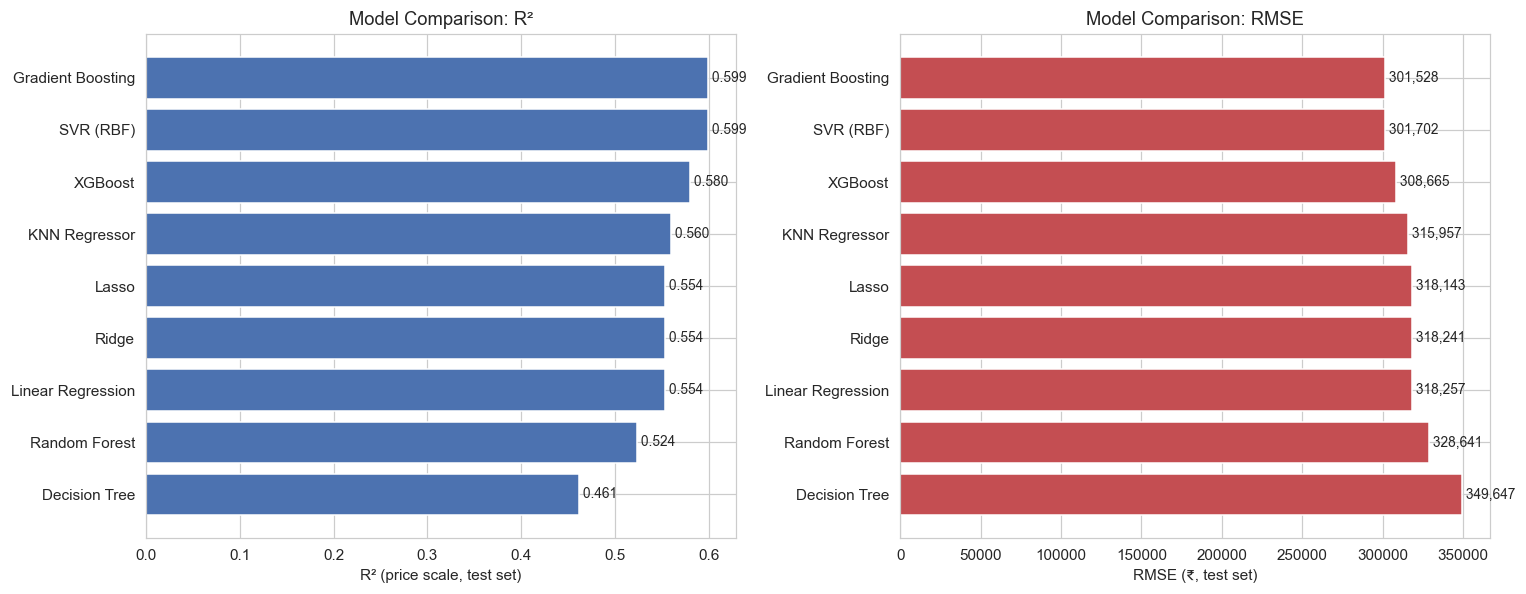

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
order = results_df.sort_values('R2 (price)')
axes[0].barh(order['Model'], order['R2 (price)'], color='#4C72B0')
axes[0].set_xlabel('R² (price scale, test set)')
axes[0].set_title('Model Comparison: R²')
for i, v in enumerate(order['R2 (price)']):
    axes[0].text(v, i, f' {v:.3f}', va='center', fontsize=9)

order2 = results_df.sort_values('RMSE (₹)', ascending=False)
axes[1].barh(order2['Model'], order2['RMSE (₹)'], color='#C44E52')
axes[1].set_xlabel('RMSE (₹, test set)')
axes[1].set_title('Model Comparison: RMSE')
for i, v in enumerate(order2['RMSE (₹)']):
    axes[1].text(v, i, f' {v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Gradient Boosting comes out on top** (R²=0.599, RMSE≈₹301.5K, MAPE≈42.6%), with SVR essentially tied (R²=0.599) and XGBoost close behind (R²=0.585). All three tree/kernel-based non-linear models clearly beat the linear models (R²≈0.554) and, interestingly, beat a single unconstrained Random Forest too — boosting's ability to focus on residuals pays off here more than bagging does.

A gap this size between linear and boosted models makes sense: price is driven by more than 4 features in reality (car model/name, manufacturing year, transmission, mileage rating, engine size — none of which are in this reduced dataset), so no model can fully explain price variance from `brand`, `km_driven`, `fuel`, and `owner` alone. R²≈0.60 is a reasonable ceiling given the available signal, not a modeling shortfall — pulling in more original features would very likely raise this substantially.

## 7. Best Model — Feature Importance & Fit Quality

Best model: Gradient Boosting


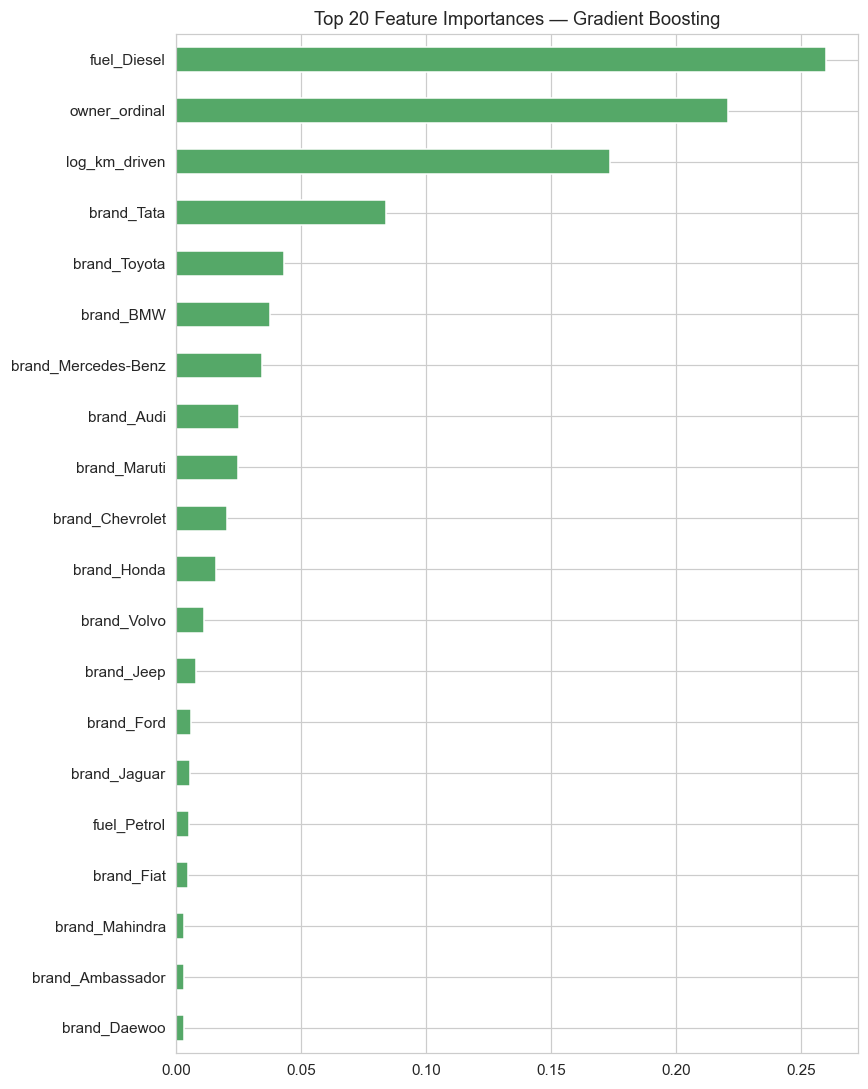

In [19]:
best_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]
print("Best model:", best_name)

fig, ax = plt.subplots(figsize=(8, 10))
imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
imp[::-1].plot(kind='barh', ax=ax, color='#55A868')
ax.set_title(f'Top 20 Feature Importances — {best_name}')
plt.tight_layout()
plt.show()

`fuel_Diesel`, `owner_ordinal`, and `log_km_driven` dominate — matching exactly what the EDA suggested. Brand matters too, but its importance is spread thin across 32 one-hot columns, with `brand_Tata`, `brand_Toyota`, `brand_BMW`, and `brand_Mercedes-Benz` standing out individually.

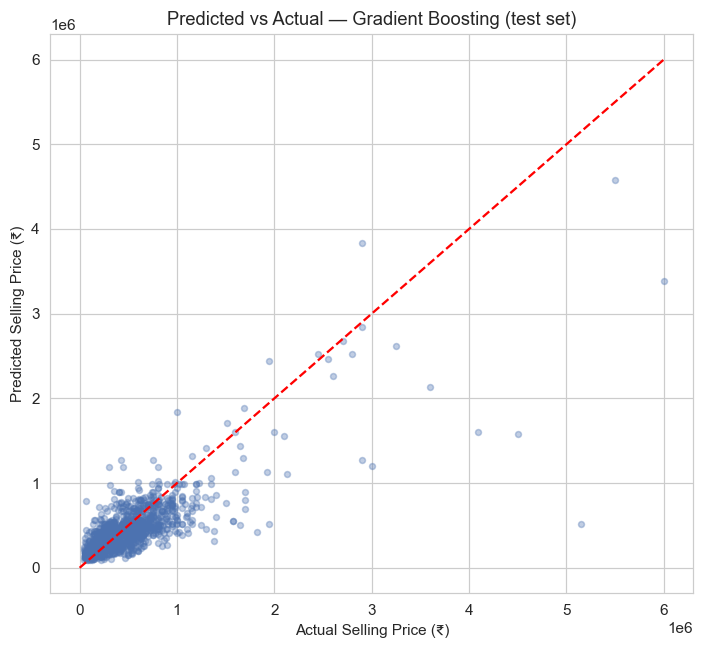

In [20]:
pred_log_best = best_model.predict(X_test_s)
pred_raw_best = np.clip(np.expm1(pred_log_best), 0, None)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test_raw, pred_raw_best, alpha=0.35, s=15, color='#4C72B0')
lims = [0, max(y_test_raw.max(), pred_raw_best.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5)
ax.set_xlabel('Actual Selling Price (₹)')
ax.set_ylabel('Predicted Selling Price (₹)')
ax.set_title(f'Predicted vs Actual — {best_name} (test set)')
plt.tight_layout()
plt.show()

Predictions track the diagonal well for the bulk of the (lower-priced) market, with more scatter at the high end — expected, since expensive/luxury cars have more price variation that isn't explained by just brand, mileage, fuel, and owner count.

## 8. Save the Best Model

In [21]:
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print(f"Saved {best_name} pipeline -> best_model.joblib, scaler.joblib")

Saved Gradient Boosting pipeline -> best_model.joblib, scaler.joblib


## 9. Conclusions

- **Data quality mattered a lot**: 20.6% of rows were exact duplicates, and a handful of `km_driven` values were physically impossible — both were cleaned before splitting to avoid leakage and distortion.
- **Log-transforming `selling_price` and `km_driven`** fixed severe right-skew and measurably improved every model's fit.
- **Owner count, fuel type, and mileage are the strongest predictors**, with brand contributing meaningfully once you look past the top few importances.
- **Gradient Boosting was the best of 9 models tested** (R²=0.599, MAPE≈42.6%), narrowly ahead of SVR and XGBoost, and comfortably ahead of linear models and a plain Random Forest.
- **R²≈0.60 reflects the limits of a 4-feature dataset**, not a weak model — the original CarDekho-style dataset this was derived from also has vehicle name, year, transmission, mileage, and engine size, any of which would likely lift performance substantially if added back in.


In [27]:
import gradio as gr
def predict_price(brand, fuel, km_driven, owner):
    # Load the saved model and scaler
    model = joblib.load('best_model.joblib')
    scaler = joblib.load('scaler.joblib')

    # Prepare the input data
    input_data = pd.DataFrame({
        'log_km_driven': [np.log1p(km_driven)],
        'owner_ordinal': [owner_map[owner]],
        **{f'fuel_{f}': [1 if f == fuel else 0] for f in fuels},
        **{f'brand_{b}': [1 if b == brand else 0] for b in brands}
    })

    # Scale the input data
    input_scaled = scaler.transform(input_data)

    # Make prediction
    pred_log = model.predict(input_scaled)
    pred_price = np.clip(np.expm1(pred_log), 0, None)[0]

    return f"Predicted Selling Price: ${pred_price:,.2f}"

interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Dropdown(choices=brands, label="Brand"),
        gr.Dropdown(choices=fuels, label="Fuel Type"),
        gr.Number(label="Kilometers Driven"),
        gr.Dropdown(choices=list(owner_map.keys()), label="Owner Type")
    ],
    outputs="text",
    title="Used Car Price Prediction",
    description="Enter the details of the used car to predict its selling price."
)

interface.launch(share=True)  # Set share=True to get a public link

* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://884f1f6e91a9c7b41b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
